# 02 - Exploratory Data Analysis & Randomization Validation

**Objective:** Before running any statistical tests, validate experiment integrity.

This notebook covers:
1. Loading and exploring the dataset
2. Checking for Sample Ratio Mismatch (SRM)
3. Validating covariate balance between groups
4. Checking for temporal patterns and novelty effects

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load the Data

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/ab_test_data.csv')

# Parse dates
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Basic info
print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df['signup_date'].min().date()} to {df['signup_date'].max().date()}")
print(f"\nColumns: {list(df.columns)}")

Dataset shape: (50000, 10)

Date range: 2025-01-06 to 2025-02-02

Columns: ['user_id', 'signup_date', 'variant', 'company_size', 'plan_type', 'traffic_source', 'device', 'actions_completed', 'activated_7d', 'activated_14d']


In [3]:
# Preview the data
df.head(10)

,user_id,signup_date,variant,company_size,plan_type,traffic_source,device,actions_completed,activated_7d,activated_14d
0,user_032259,2025-01-06,control,smb,free_trial,organic,desktop,8,True,True
1,user_042312,2025-01-06,control,mid_market,free_trial,organic,desktop,2,False,False
2,user_003073,2025-01-06,control,smb,paid,organic,desktop,0,False,False
3,user_042311,2025-01-06,control,smb,paid,paid_ads,desktop,17,True,True
4,user_028995,2025-01-06,control,smb,free_trial,paid_ads,desktop,0,False,False
5,user_029001,2025-01-06,control,mid_market,paid,referral,desktop,8,True,True
6,user_042288,2025-01-06,control,smb,free_trial,organic,mobile,1,False,False
7,user_029017,2025-01-06,control,smb,free_trial,organic,desktop,9,True,True
8,user_029030,2025-01-06,treatment,smb,free_trial,paid_ads,mobile,14,False,True
9,user_042265,2025-01-06,control,smb,free_trial,paid_ads,desktop,0,False,False


In [4]:
# Data types and missing values
print("Data Types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")

Data Types:
user_id                      object
signup_date          datetime64[ns]
variant                      object
company_size                 object
plan_type                    object
traffic_source               object
device                       object
actions_completed             int64
activated_7d                   bool
activated_14d                  bool
dtype: object

Missing values: 0


## 2. Sample Ratio Mismatch (SRM) Check

The first and most critical check: **Is the split actually 50/50?**

A Sample Ratio Mismatch indicates a potential bug in the randomization system. Even a small deviation from expected ratios can indicate serious problems.

We use a chi-squared test to check if the observed split differs significantly from expected.

In [5]:
# Count users per variant
variant_counts = df['variant'].value_counts()
print("Variant Distribution:")
print(variant_counts)
print(f"\nRatio: {variant_counts['treatment'] / variant_counts['control']:.4f} (expected: 1.0)")

Variant Distribution:
variant
treatment    25035
control      24965
Name: count, dtype: int64

Ratio: 1.0028 (expected: 1.0)


In [6]:
def check_srm(observed_counts, expected_ratio=0.5, alpha=0.05):
    """
    Check for Sample Ratio Mismatch using chi-squared test.
    
    Parameters
    ----------
    observed_counts : dict or Series
        Observed counts per group
    expected_ratio : float
        Expected proportion for each group (default 50/50)
    alpha : float
        Significance level for the test
        
    Returns
    -------
    dict
        Test results including chi-squared statistic and p-value
    """
    total = sum(observed_counts)
    expected_counts = [total * expected_ratio, total * (1 - expected_ratio)]
    observed = list(observed_counts)
    
    # Chi-squared test
    chi2, p_value = stats.chisquare(observed, expected_counts)
    
    # Interpret
    has_srm = p_value < alpha
    
    return {
        'chi2_statistic': chi2,
        'p_value': p_value,
        'has_srm': has_srm,
        'observed': observed,
        'expected': expected_counts
    }

# Run SRM check
srm_result = check_srm(variant_counts.values)

print("\n" + "="*50)
print("SAMPLE RATIO MISMATCH CHECK")
print("="*50)
print(f"Chi-squared statistic: {srm_result['chi2_statistic']:.4f}")
print(f"P-value: {srm_result['p_value']:.4f}")
print(f"\nConclusion: ", end="")

if srm_result['has_srm']:
    print("⚠️  WARNING: Sample Ratio Mismatch detected!")
    print("This indicates a potential problem with randomization.")
else:
    print("✓ No SRM detected. Randomization appears correct.")


SAMPLE RATIO MISMATCH CHECK
Chi-squared statistic: 0.0980
P-value: 0.7542

Conclusion: ✓ No SRM detected. Randomization appears correct.


## 3. Covariate Balance Check

Even with correct randomization, we should verify that key covariates are balanced between groups.

**Why this matters:** If groups differ on covariates (e.g., more enterprise users in treatment), observed effects might be due to these differences, not the treatment.

In [7]:
# Categorical covariates to check
categorical_vars = ['company_size', 'plan_type', 'traffic_source', 'device']

print("="*60)
print("COVARIATE BALANCE CHECK - CATEGORICAL VARIABLES")
print("="*60)

balance_results = []

for var in categorical_vars:
    # Create contingency table
    contingency = pd.crosstab(df[var], df['variant'])
    
    # Chi-squared test for independence
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    # Calculate proportions
    props = df.groupby('variant')[var].value_counts(normalize=True).unstack(fill_value=0)
    
    balance_results.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p_value,
        'balanced': p_value >= 0.05
    })
    
    print(f"\n{var.upper()}")
    print("-" * 40)
    print(props.T.round(4))
    print(f"Chi-squared: {chi2:.4f}, p-value: {p_value:.4f}")
    print(f"Status: {'✓ Balanced' if p_value >= 0.05 else '⚠️ Imbalanced'}")

# Summary table
balance_df = pd.DataFrame(balance_results)
print("\n" + "="*60)
print("BALANCE SUMMARY")
print("="*60)
print(balance_df.to_string(index=False))

COVARIATE BALANCE CHECK - CATEGORICAL VARIABLES

COMPANY_SIZE
----------------------------------------
variant       control  treatment
company_size                    
enterprise     0.0995     0.1011
mid_market     0.2965     0.2975
smb            0.6040     0.6013
Chi-squared: 0.5519, p-value: 0.7588
Status: ✓ Balanced

PLAN_TYPE
----------------------------------------
variant     control  treatment
plan_type                     
free_trial   0.6159     0.6216
paid         0.3841     0.3784
Chi-squared: 1.7504, p-value: 0.1858
Status: ✓ Balanced

TRAFFIC_SOURCE
----------------------------------------
variant         control  treatment
traffic_source                    
organic          0.4991     0.4999
paid_ads         0.3497     0.3517
referral         0.1512     0.1484
Chi-squared: 0.8247, p-value: 0.6621
Status: ✓ Balanced

DEVICE
----------------------------------------
variant  control  treatment
device                     
desktop   0.8115     0.8168
mobile    0.1885     0.

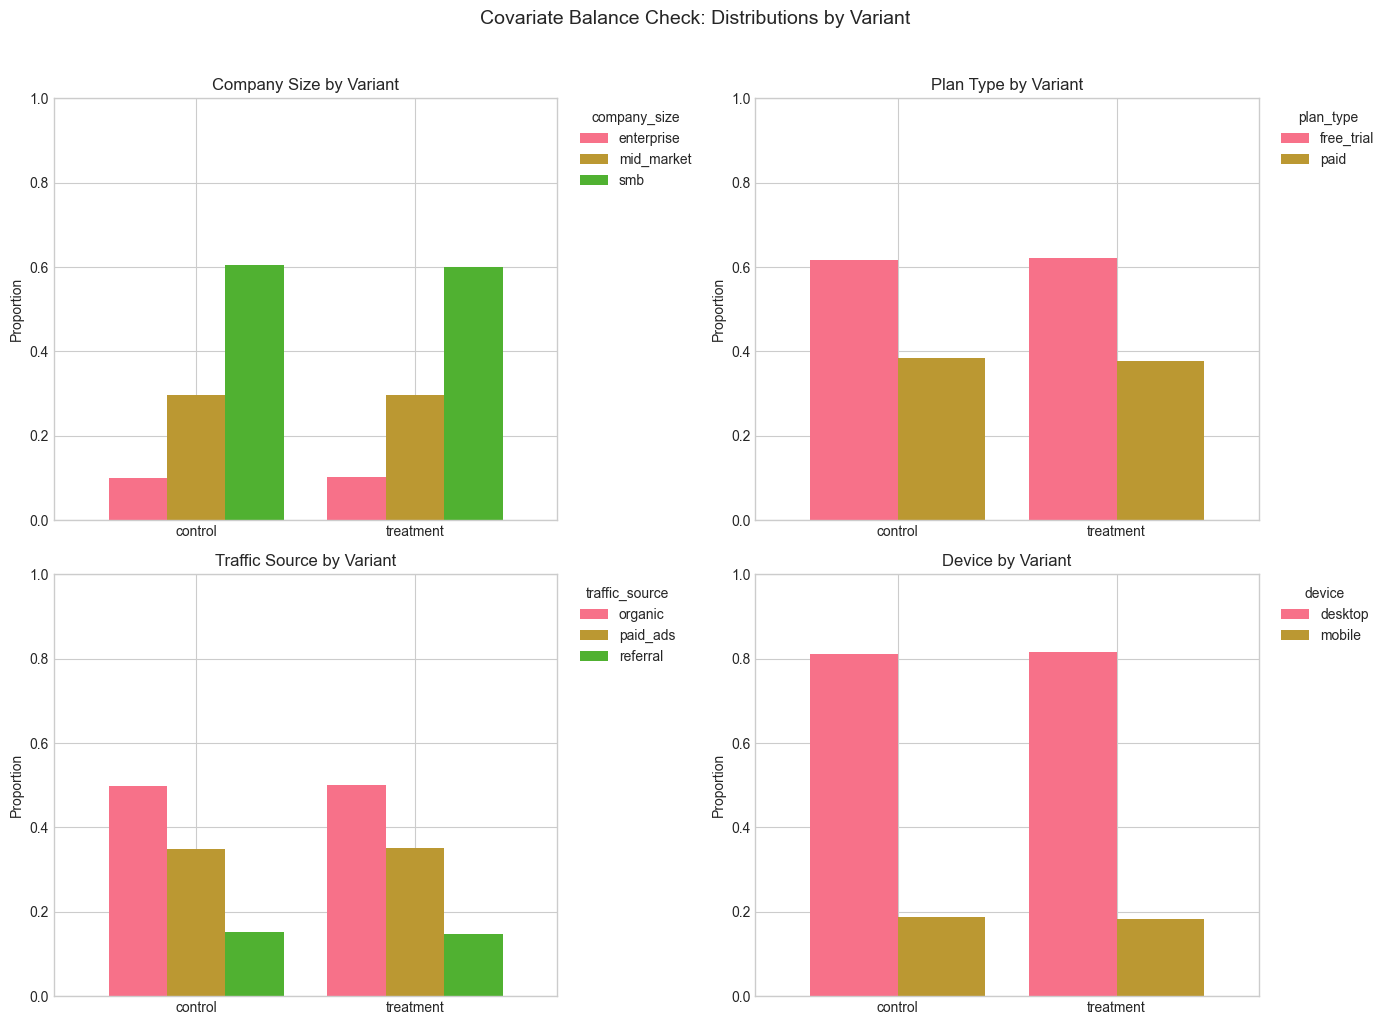

In [8]:
# Visualize covariate balance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var in zip(axes.flatten(), categorical_vars):
    props = df.groupby(['variant', var]).size().unstack(fill_value=0)
    props = props.div(props.sum(axis=1), axis=0)  # Normalize to proportions
    
    props.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'{var.replace("_", " ").title()} by Variant', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')
    ax.legend(title=var, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(0, 1)

plt.suptitle('Covariate Balance Check: Distributions by Variant', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Temporal Patterns

Check if there are any time-based anomalies:
- Is the split consistent over time?
- Are there any date-specific issues?

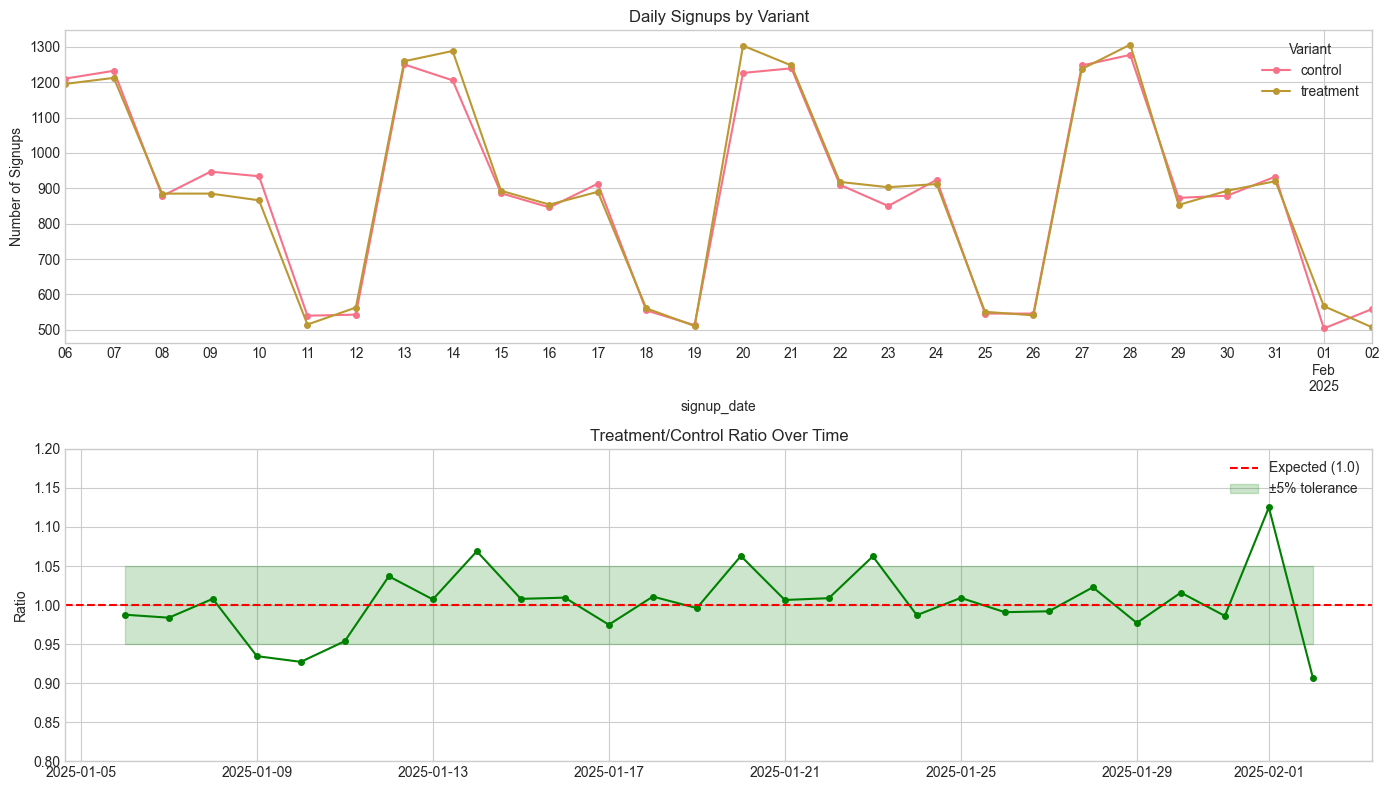


Ratio statistics:
  Mean: 1.0021
  Std:  0.0444
  Min:  0.9070
  Max:  1.1250


In [9]:
# Daily signups by variant
daily_signups = df.groupby(['signup_date', 'variant']).size().unstack(fill_value=0)
daily_signups['ratio'] = daily_signups['treatment'] / daily_signups['control']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Daily signups
daily_signups[['control', 'treatment']].plot(ax=axes[0], marker='o', markersize=4)
axes[0].set_title('Daily Signups by Variant', fontsize=12)
axes[0].set_ylabel('Number of Signups')
axes[0].legend(title='Variant')

# Plot 2: Daily ratio
axes[1].plot(daily_signups.index, daily_signups['ratio'], 'g-', marker='o', markersize=4)
axes[1].axhline(y=1.0, color='red', linestyle='--', label='Expected (1.0)')
axes[1].fill_between(daily_signups.index, 0.95, 1.05, alpha=0.2, color='green', label='±5% tolerance')
axes[1].set_title('Treatment/Control Ratio Over Time', fontsize=12)
axes[1].set_ylabel('Ratio')
axes[1].set_ylim(0.8, 1.2)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nRatio statistics:")
print(f"  Mean: {daily_signups['ratio'].mean():.4f}")
print(f"  Std:  {daily_signups['ratio'].std():.4f}")
print(f"  Min:  {daily_signups['ratio'].min():.4f}")
print(f"  Max:  {daily_signups['ratio'].max():.4f}")

## 5. Conversion Rates Over Time (Novelty Effect Check)

Look for novelty effects: does the treatment effect change over time?
- Initial spike that fades = novelty effect
- Stable over time = real effect

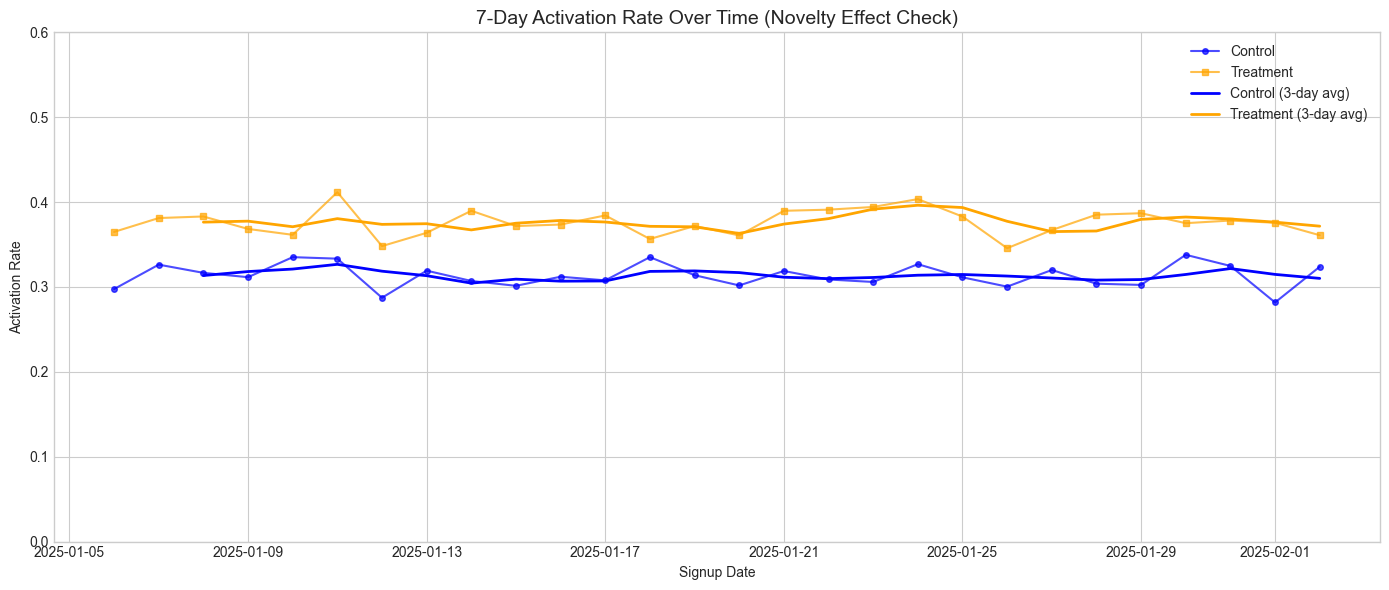

In [10]:
# Daily activation rate by variant
daily_activation = df.groupby(['signup_date', 'variant'])['activated_7d'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))

# Plot activation rates
ax.plot(daily_activation.index, daily_activation['control'], 
        'b-', marker='o', markersize=4, label='Control', alpha=0.7)
ax.plot(daily_activation.index, daily_activation['treatment'], 
        'orange', marker='s', markersize=4, label='Treatment', alpha=0.7)

# Add rolling averages
window = 3
ax.plot(daily_activation.index, daily_activation['control'].rolling(window).mean(), 
        'b-', linewidth=2, label=f'Control ({window}-day avg)')
ax.plot(daily_activation.index, daily_activation['treatment'].rolling(window).mean(), 
        'orange', linewidth=2, label=f'Treatment ({window}-day avg)')

ax.set_title('7-Day Activation Rate Over Time (Novelty Effect Check)', fontsize=14)
ax.set_xlabel('Signup Date')
ax.set_ylabel('Activation Rate')
ax.legend()
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show()

In [11]:
# Check for novelty effect: compare first week vs last week
df['week'] = df['signup_date'].dt.isocalendar().week

weekly_effect = df.groupby(['week', 'variant'])['activated_7d'].mean().unstack()
weekly_effect['lift'] = weekly_effect['treatment'] - weekly_effect['control']

print("Weekly Activation Rates and Lift:")
print(weekly_effect.round(4))

# Statistical test: is the lift different between weeks?
first_week = df[df['week'] == df['week'].min()]
last_week = df[df['week'] == df['week'].max()]

lift_first = (first_week[first_week['variant']=='treatment']['activated_7d'].mean() - 
              first_week[first_week['variant']=='control']['activated_7d'].mean())
lift_last = (last_week[last_week['variant']=='treatment']['activated_7d'].mean() - 
             last_week[last_week['variant']=='control']['activated_7d'].mean())

print(f"\nFirst week lift: {lift_first:.4f}")
print(f"Last week lift:  {lift_last:.4f}")
print(f"Difference: {lift_last - lift_first:.4f}")

if abs(lift_last - lift_first) < 0.02:
    print("\n✓ Treatment effect appears stable over time (no strong novelty effect)")
else:
    print("\nTreatment effect may be changing over time (potential novelty effect)")

Weekly Activation Rates and Lift:
variant  control  treatment   lift
week                              
2         0.3157     0.3731 0.0574
3         0.3126     0.3745 0.0619
4         0.3112     0.3823 0.0711
5         0.3147     0.3766 0.0618

First week lift: 0.0574
Last week lift:  0.0618
Difference: 0.0044

✓ Treatment effect appears stable over time (no strong novelty effect)


## 6. Data Quality Summary

In [12]:
print("\n" + "="*60)
print("DATA VALIDATION SUMMARY")
print("="*60)

checks = [
    ("Sample Ratio Mismatch", not srm_result['has_srm']),
    ("Covariate Balance", all(balance_df['balanced'])),
    ("No Missing Data", df.isnull().sum().sum() == 0),
    ("Stable Treatment Effect", abs(lift_last - lift_first) < 0.02)
]

for check_name, passed in checks:
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"  {status}: {check_name}")

all_passed = all(passed for _, passed in checks)

print("\n" + "-"*60)
if all_passed:
    print("✓ All validation checks passed. Data is ready for analysis.")
else:
    print("⚠️ Some checks failed. Review issues before proceeding.")


DATA VALIDATION SUMMARY
  ✓ PASS: Sample Ratio Mismatch
  ✓ PASS: Covariate Balance
  ✓ PASS: No Missing Data
  ✓ PASS: Stable Treatment Effect

------------------------------------------------------------
✓ All validation checks passed. Data is ready for analysis.


## 7. Quick Look at Outcome Variable

In [13]:
# Overall activation rates
print("\nOverall Activation Rates:")
print(df.groupby('variant')[['activated_7d', 'activated_14d']].mean().round(4))

# Lift calculation
control_rate = df[df['variant'] == 'control']['activated_7d'].mean()
treatment_rate = df[df['variant'] == 'treatment']['activated_7d'].mean()

absolute_lift = treatment_rate - control_rate
relative_lift = absolute_lift / control_rate

print(f"\n7-Day Activation:")
print(f"  Control:   {control_rate:.4f}")
print(f"  Treatment: {treatment_rate:.4f}")
print(f"  Absolute Lift: {absolute_lift:+.4f} ({absolute_lift*100:+.2f} pp)")
print(f"  Relative Lift: {relative_lift:+.2%}")


Overall Activation Rates:
           activated_7d  activated_14d
variant                               
control          0.3136         0.3817
treatment        0.3767         0.4512

7-Day Activation:
  Control:   0.3136
  Treatment: 0.3767
  Absolute Lift: +0.0631 (+6.31 pp)
  Relative Lift: +20.13%


---

## Next Steps

Data validation is complete! Now we can proceed with statistical analysis:

**→ Notebook 03: Frequentist Hypothesis Testing**

We'll run z-tests, calculate confidence intervals, and determine statistical significance.